# Trabajo Práctico 1: Un clima estresante
## Alumnos: Córdoba Lucía, Gagliardi Lara y Sánchez Joaquín

introduction

### Carga de módulos

In [1]:
import polars as pl

import pyprojroot

import matplotlib.pyplot as plt
import seaborn as sns

from plotnine import *

import math

ROOT = pyprojroot.here()

### Carga de datos

En primer lugar, cargamos los datos meteorológicos de la ciudad rural en los años 2019 a 2023.

In [2]:
atmosfera19 = pl.read_csv(ROOT / "2019" / "atmosfera.csv")
energia19 = pl.read_csv(ROOT / "2019" / "energia.csv")
lluvias19 = pl.read_csv(ROOT / "2019" / "lluvias.csv")

atmosfera20 = pl.read_csv(ROOT / "2020" / "atmosfera.csv")
energia20 = pl.read_csv(ROOT / "2020" / "energia.csv")
lluvias20 = pl.read_csv(ROOT / "2020" / "lluvias.csv")

atmosfera21 = pl.read_csv(ROOT / "2021" / "atmosfera.csv")
energia21 = pl.read_csv(ROOT / "2021" / "energia.csv")
lluvias21 = pl.read_csv(ROOT / "2021" / "lluvias.csv")

atmosfera22 = pl.read_csv(ROOT / "2022" / "atmosfera.csv")
energia22 = pl.read_csv(ROOT / "2022" / "energia.csv")
lluvias22 = pl.read_csv(ROOT / "2022" / "lluvias.csv")

atmosfera23 = pl.read_csv(ROOT / "2023" / "atmosfera.csv")
energia23 = pl.read_csv(ROOT / "2023" / "energia.csv")
lluvias23 = pl.read_csv(ROOT / "2023" / "lluvias.csv")

Luego, unimos los datos en una única base de datos.

In [3]:
datos2019 = atmosfera19.join(energia19, on = "fecha", how = "inner").join(lluvias19, on = "fecha", how = "inner")
datos2020 = atmosfera20.join(energia20, on = "fecha", how = "inner").join(lluvias20, on = "fecha", how = "inner")
datos2021 = atmosfera21.join(energia21, on = "fecha", how = "inner").join(lluvias21, on = "fecha", how = "inner")
datos2022 = atmosfera22.join(energia22, on = "fecha", how = "inner").join(lluvias22, on = "fecha", how = "inner")
datos2023 = atmosfera23.join(energia23, on = "fecha", how = "inner").join(lluvias23, on = "fecha", how = "inner")

datos = pl.concat([datos2019, datos2020, datos2021, datos2022, datos2023], how = "vertical")

In [4]:
observaciones_total = datos.shape
observaciones_total

(1826, 8)

En el conjunto de datos hay 1826 observaciones. En los años 2019, 2021, 2022 y 2023 se registraron 365 observaciones mientras que en el año 2020 hay 366 observaciones debido a que este fue un año bisiesto.

In [5]:
datos.null_count()

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


En ninguna de las variables se presentaron valores faltantes.

## ¿Cuál es la cantidad total de lluvia caída en la zona? ¿Y cuánto se corresponde a cada año? Realice un gráfico de barras.

In [ ]:
lluvia_total = datos["lluvia"].sum()

# Agregamos una columna con el año
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.year()
    .alias("anio")
)

lluvia_por_anio = (
    datos
    .group_by("anio")
    .agg(
    pl.col("lluvia").sum().alias("lluvia_total")
    )
    .sort("anio")
)

lluvia_por_anio

### Estará bien la tabla? o pretendía que respondamos a la pregunta solo con el gráfico de barras??

anio,lluvia_total
i32,f64
2019,346.6
2020,811.6
2021,950.4
2022,1476.2
2023,743.0


La cantidad total de lluvia caída en la zona rural es de 4327.79 milímetros (mm). El año 2019 fue el año con menores precipitaciones (346.6 mm) mientras que el año 2022 presentó la mayor cantidad de milímentros llovidos (1476.2 mm)

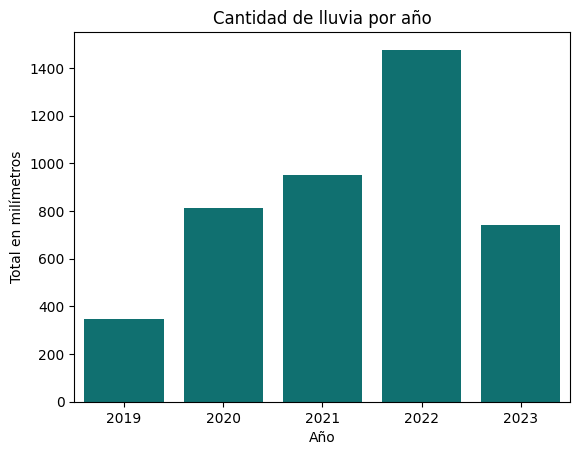

In [10]:
datos_agrupado_anio = (
    datos
    .group_by("anio")
    .agg(
        pl.col("lluvia")
        .sum()
        .alias("total")
        )
)

sns.barplot(
    x = "anio", 
    y = "total", 
    color = "teal",
    data = datos_agrupado_anio 
    )
plt.title(
    "Cantidad de lluvia por año"
)

plt.xlabel("Año")
plt.ylabel("Total en milímetros");

Interpretación de arriba

Después, graficamos la cantidad de lluvia por mes y año a través de un gráfico de líneas.

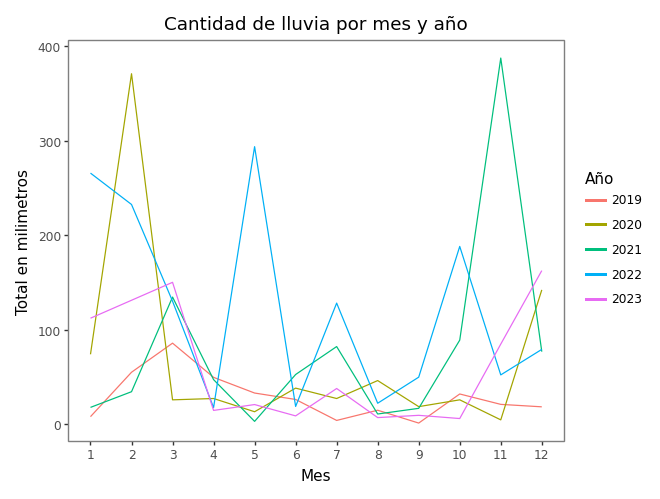

In [11]:
# Agregamos una columna con el mes
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.month()
    .alias("mes")
)

datos_agrupado_anio_mes = (
    datos
    .group_by("anio", "mes")
    .agg(
        pl.col("lluvia")
        .sum()
        .alias("total")
        )
    .sort(["anio", "mes"])
)

grafico = (
    ggplot(datos_agrupado_anio_mes) +  
    aes(x = "mes", y = "total", color = "factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks = range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de lluvia por mes y año",
        x = "Mes",
        y = "Total en milimetros",
        color = "Año"
    ) +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
    )
)

grafico

En el gráfico anterior se observa que no hay un patrón muy marcado del total de mm llovidos a través de los años. En general, en los primeros y últimos meses del año hay un aumento de precipitaciones mientras que en el resto de los meses la cantidad de precipitaciones es baja. (REVISAR!!!!!!!!!!)

Para analizar cómo varía las temperaturas máximas y mínimas a lo largo del tiempo graficamos el promedio de las temperaturas para cada mes en todos los años.

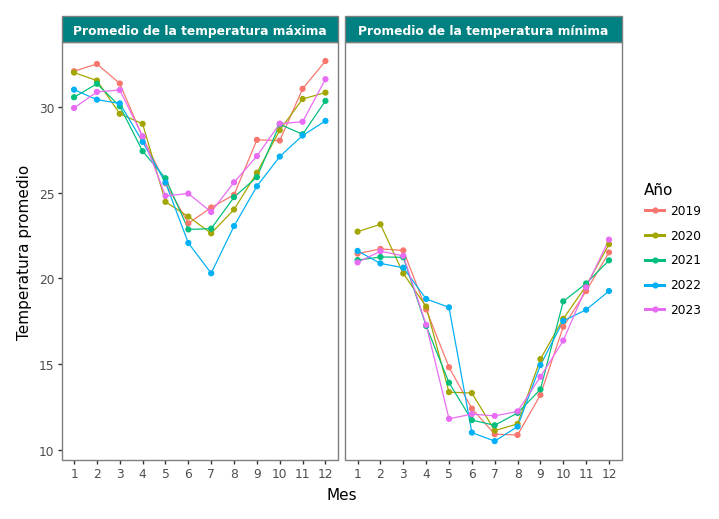

In [12]:
datos_temp_mes = (
    datos
    .group_by("mes", "anio")
    .agg(
        pl.col("t_min")
        .mean()
        .alias("Promedio de la temperatura mínima"), 
        pl.col("t_max")
        .mean()
        .alias("Promedio de la temperatura máxima"),
        pl.col("fecha").min()
        )
        .sort("anio", "mes")
)
datos_temp_mes

# Para poder graficar ambas temperaturas promedios usando facet_wrap() es necesario que 
# haya una columna que indique si la temperatura es máxima o mínima por lo que es necesario
# que las temperaturas promedios se encuentren en una misma columna, es decir, hay que 
# pasarlo a formato largo

datos_temp_mes_largo = (
    datos_temp_mes
    .unpivot(
        index = ["mes", "anio"],
        on = ["Promedio de la temperatura mínima", "Promedio de la temperatura máxima"],
        variable_name = "tipo",
        value_name = "promedio_t"
    )
)

(
ggplot(datos_temp_mes_largo) +
aes(
    x = "mes",
    y = "promedio_t",
    color = "factor(anio)"
    ) +
geom_line() +
geom_point() +
facet_wrap("~tipo") +
scale_x_continuous(breaks = range(1, 13)) +
theme_bw() +
labs(
    x = "Mes",
    y = "Temperatura promedio",
    color = "Año"
    ) +
theme(    
    figure_size=(7, 5),
    panel_grid_minor = element_blank(),
    panel_grid_major = element_blank(),
    strip_background = element_rect(fill = "teal", color = None),
    strip_text = element_text(color = "white", weight = "bold")
    )
)

En los meses de invierno las temperaturas son más bajas 

## Obtenga un gráfico que permita ver la asociación entre la temperatura mínima y máxima.

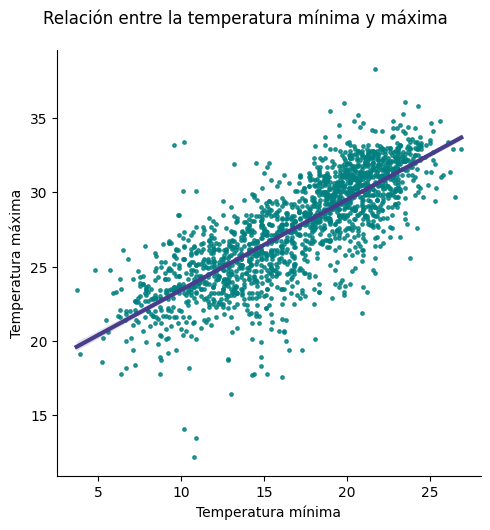

In [13]:
g = sns.lmplot(
    data = datos, 
    x = "t_min", 
    y = "t_max",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura mínima")
g.set_ylabels("Temperatura máxima")
g.set_titles("Relación entre la temperatura mínima y máxima")
g.fig.suptitle(
    "Relación entre la temperatura mínima y máxima",
    y=1.05
);

Relación positiva

Calculamos la amplitud térmica

In [14]:
datos = datos.with_columns(
    amplitud_termica = pl.col("t_max") - pl.col("t_min")
)

## Visualice el comportamiento de la amplitud térmica:
### Globalmente y a lo largo del tiempo.

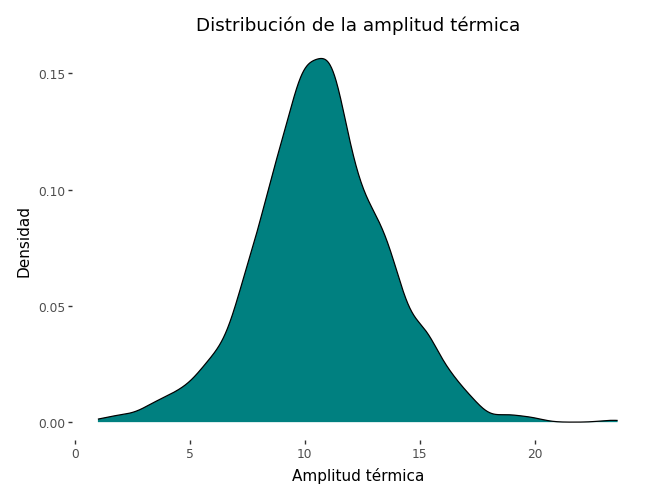

In [15]:
# Globalmente
(
ggplot(datos) + 
geom_density(
    aes("amplitud_termica"),
    fill = "teal"
    ) + 
labs(
    x = "Amplitud térmica",
    y = "Densidad",
    title = "Distribución de la amplitud térmica"
    ) + 
theme(    
    panel_grid_minor = element_blank(),
    panel_grid_major = element_blank(),
    panel_background = element_blank()
    )
)


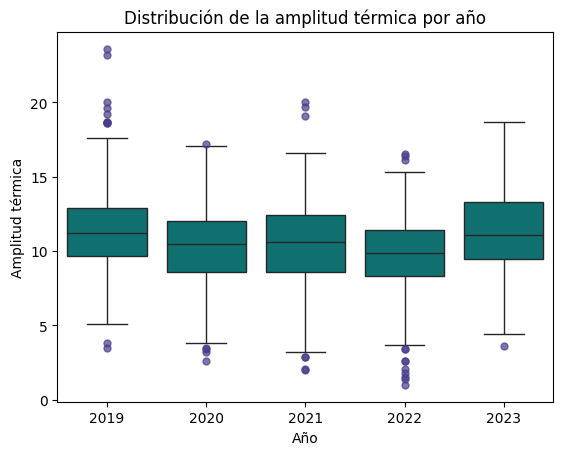

In [16]:
# a lo largo del tiempo
g = sns.boxplot(
    x = "anio", 
    y = "amplitud_termica", 
    color = "teal",
    data = datos,
    flierprops={
    "marker": "o",
    "markerfacecolor": "darkslateblue",
    "markeredgecolor": "darkslateblue",
    "markersize": 5,
    "alpha": 0.7
    })
g.set_xlabel("Año")
g.set_ylabel("Amplitud térmica")
g.set_title("Distribución de la amplitud térmica por año");

### ¿Hay alguna asociación entre la amplitud térmica y la temperatura mínima o máxima del día?

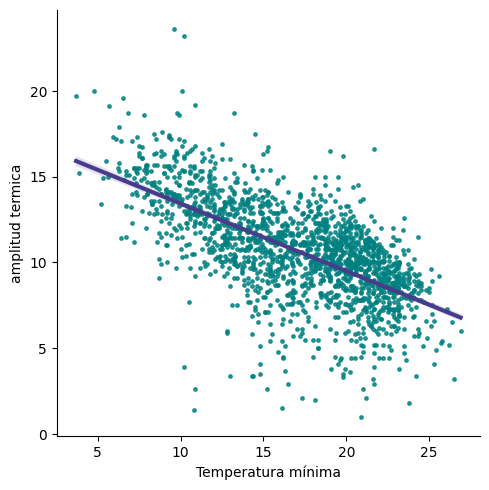

In [17]:
g = sns.lmplot(data = datos, x = "t_min", y = "amplitud_termica",
    scatter_kws={"s": 6, "color": "teal"},
    line_kws={"color": "darkslateblue", "linewidth": 3}
)
g.set_xlabels("Temperatura mínima")
g.set_ylabels("amplitud termica");


In [18]:
datos.select(
    pl.corr("t_min", "amplitud_termica")
)

t_min
f64
-0.635425


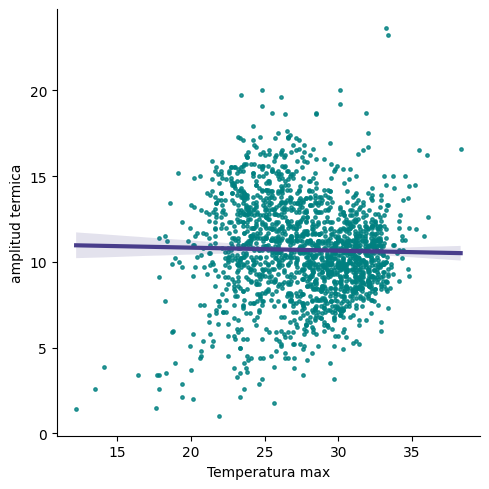

In [19]:
g = sns.lmplot(data = datos, x = "t_max", y = "amplitud_termica",
    scatter_kws={"s": 6, "color": "teal"},
    line_kws={"color": "darkslateblue", "linewidth": 3}
)
g.set_xlabels("Temperatura max")
g.set_ylabels("amplitud termica");

In [20]:
datos.select(
    pl.corr("amplitud_termica", "t_max")
)

amplitud_termica
f64
-0.021824


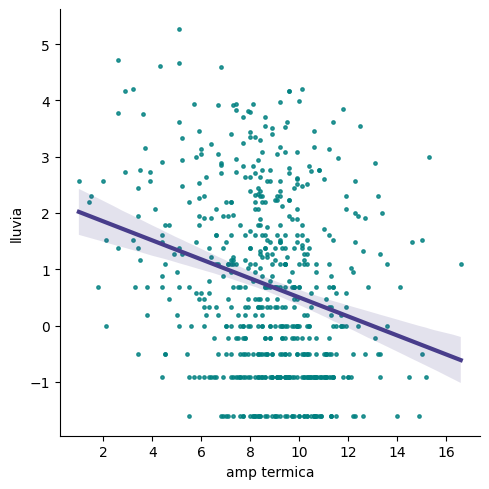

In [21]:
datos_con_lluvia = datos.filter(pl.col("lluvia") != 0)
datos_con_lluvia = datos_con_lluvia.with_columns(
    pl.col("lluvia").log().alias("log_lluvia")
)

g = sns.lmplot(data = datos_con_lluvia, y = "log_lluvia", x = "amplitud_termica",
    scatter_kws={"s": 6, "color": "teal"},
    line_kws={"color": "darkslateblue", "linewidth": 3}
)
g.set_xlabels("amp termica")
g.set_ylabels("lluvia");



In [22]:
datos.select(
    pl.corr("lluvia", "amplitud_termica")
)

lluvia
f64
-0.267443


## ¿Cuál es el mes (o los meses) que suelen recibir mayor radiación?

In [23]:
datos.group_by("mes").agg(pl.col("radiación").mean().alias("prom_rad")).sort("prom_rad", descending=True)

mes,prom_rad
i8,f64
12,25.363226
1,24.005806
11,23.785333
2,22.77305
10,22.729032
…,…
4,17.395333
8,17.171613
5,14.414839


En el verano hay más radación

### ¿En qué mes a lo largo de los 5 años de datos se observó el mayor nivel de evaporación?

In [24]:
datos.group_by("anio", "mes").agg(pl.col("evaporación").sum()).sort("evaporación").tail(1)

anio,mes,evaporación
i32,i8,f64
2019,12,274.2


### Estrés

In [25]:
datos_estres = datos.with_columns(
    pl.when(pl.col('t_max') >= 32)
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias('estres')
)
datos_estres

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia,anio,mes,amplitud_termica,estres
str,f64,f64,f64,f64,f64,f64,f64,i32,i8,f64,i32
"""2019-01-01""",20.3,31.1,87.8,46.3,8.5,29.6,0.0,2019,1,10.8,0
"""2019-01-02""",20.1,31.2,99.1,51.3,7.7,27.1,0.0,2019,1,11.1,0
"""2019-01-03""",20.3,31.8,100.0,55.5,6.7,26.5,1.0,2019,1,11.5,0
"""2019-01-04""",21.0,31.2,74.4,40.7,9.4,29.3,0.0,2019,1,10.2,0
"""2019-01-05""",22.4,31.4,83.8,49.4,8.0,23.7,0.0,2019,1,9.0,0
…,…,…,…,…,…,…,…,…,…,…,…
"""2023-12-27""",20.6,30.4,100.0,64.3,6.3,22.2,11.6,2023,12,9.8,0
"""2023-12-28""",23.6,32.2,100.0,62.0,7.3,22.4,0.0,2023,12,8.6,1
"""2023-12-29""",25.0,33.3,100.0,62.2,7.6,27.1,1.4,2023,12,8.3,1


### Cuántos días de estrés térmico se observan entre el 2019-10-14 y el 2019-12-03

In [26]:
datos_estres.filter(pl.col("fecha") >= "2019-10-14", pl.col("fecha") <= "2019-12-03")["estres"].value_counts()

estres,count
i32,u32
1,11
0,40


### Obtenga la cantidad de días de estrés térmico por mes a lo largo de los 5 años y visualícelo en un gráfico de línea.

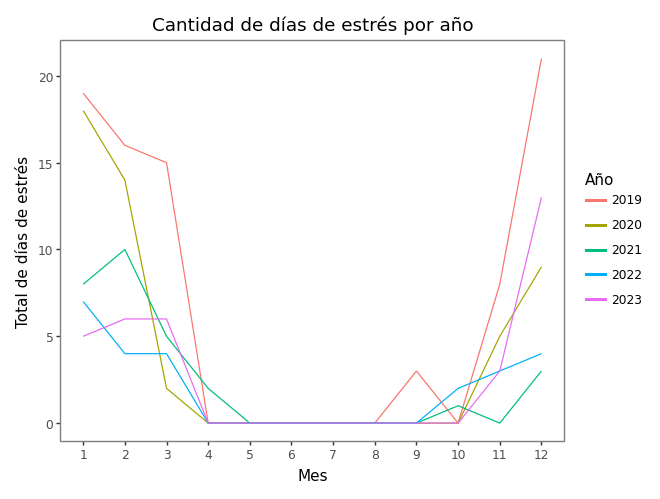

In [36]:
datos_estres_agrupado_mes_anio = (
datos_estres
.group_by("mes", "anio")
.agg(
    pl.col("estres")
    .sum()
    .alias("total")
    )
.sort("total", descending = True)
)

grafico = (
    ggplot(datos_estres_agrupado_mes_anio) +  
    aes(x = "mes", y = "total", color = "factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks = range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de días de estrés por año",
        x = "Mes",
        y = "Total de días de estrés",
        color = "Año"
    ) +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
    )
)

grafico

### Además, elabore una función que, dado el conjunto de datos, una fecha de inicio y una fecha de fin, devuelva la cantidad de días de estrés térmico dentro del rango de fechas indicado.

In [ ]:
def calcular_dias_estres (datos, inicio, fin):
    """ 
    condiciones:
        in
    """
    suma_estres = datos.filter(
        pl.col("fecha") >= inicio, pl.col("fecha") <= fin
        ).select(
        pl.col("estres").sum()
    ).item()
    return f"Entre la fecha {inicio} y la fecha {fin} hubo {suma_estres} días de estrés."

'Entre la fecha 2019-10-14 y la fecha 2020-12-03 hubo 71 días de estrés.'

## Déficit de presión de vapor

Calcule el déficit de presión de vapor en el momento que se registró la temperatura máxima

In [47]:
datos = (
    datos.with_columns(
        vps = 0.61078 * (17.27 * pl.col("t_max") / (pl.col("t_max") + 237.3)).exp()
    )
    .with_columns(
    vpa = pl.col("vps") * pl.col("hr_t_max") / 100 
    )
    .with_columns(
    vpd = pl.col("vps") - pl.col("vpa") 
    )
)
datos

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia,anio,mes,amplitud_termica,vps,vpa,vpd
str,f64,f64,f64,f64,f64,f64,f64,i32,i8,f64,f64,f64,f64
"""2019-01-01""",20.3,31.1,87.8,46.3,8.5,29.6,0.0,2019,1,10.8,4.518084,2.091873,2.426211
"""2019-01-02""",20.1,31.2,99.1,51.3,7.7,27.1,0.0,2019,1,11.1,4.543851,2.330995,2.212855
"""2019-01-03""",20.3,31.8,100.0,55.5,6.7,26.5,1.0,2019,1,11.5,4.701147,2.609137,2.09201
"""2019-01-04""",21.0,31.2,74.4,40.7,9.4,29.3,0.0,2019,1,10.2,4.543851,1.849347,2.694504
"""2019-01-05""",22.4,31.4,83.8,49.4,8.0,23.7,0.0,2019,1,9.0,4.595767,2.270309,2.325458
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2023-12-27""",20.6,30.4,100.0,64.3,6.3,22.2,11.6,2023,12,9.8,4.341248,2.791423,1.549826
"""2023-12-28""",23.6,32.2,100.0,62.0,7.3,22.4,0.0,2023,12,8.6,4.80862,2.981344,1.827276
"""2023-12-29""",25.0,33.3,100.0,62.2,7.6,27.1,1.4,2023,12,8.3,5.115246,3.181683,1.933563


variable que clasifique a los días

In [49]:
datos = datos.with_columns(
    pl.when((pl.col("vpd") >= 0) & (pl.col("vpd") < 0.5))
    .then(pl.lit("Condiciones muy húmedas"))
    
    .when((pl.col("vpd") >= 0.5) & (pl.col("vpd") < 1))
    .then(pl.lit("Condiciones moderadamente húmedas"))
    
    .when((pl.col("vpd") >= 1) & (pl.col("vpd") < 2))
    .then(pl.lit("Condiciones semiáridas"))
    
    .when((pl.col("vpd") >= 2) & (pl.col("vpd") < 3))
    .then(pl.lit("Condiciones áridas"))
    
    .otherwise(pl.lit("Condiciones extremadamente secas"))
    .alias("condicion_humedad")
)
datos

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia,anio,mes,amplitud_termica,vps,vpa,vpd,condicion_humedad
str,f64,f64,f64,f64,f64,f64,f64,i32,i8,f64,f64,f64,f64,str
"""2019-01-01""",20.3,31.1,87.8,46.3,8.5,29.6,0.0,2019,1,10.8,4.518084,2.091873,2.426211,"""Condiciones áridas"""
"""2019-01-02""",20.1,31.2,99.1,51.3,7.7,27.1,0.0,2019,1,11.1,4.543851,2.330995,2.212855,"""Condiciones áridas"""
"""2019-01-03""",20.3,31.8,100.0,55.5,6.7,26.5,1.0,2019,1,11.5,4.701147,2.609137,2.09201,"""Condiciones áridas"""
"""2019-01-04""",21.0,31.2,74.4,40.7,9.4,29.3,0.0,2019,1,10.2,4.543851,1.849347,2.694504,"""Condiciones áridas"""
"""2019-01-05""",22.4,31.4,83.8,49.4,8.0,23.7,0.0,2019,1,9.0,4.595767,2.270309,2.325458,"""Condiciones áridas"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2023-12-27""",20.6,30.4,100.0,64.3,6.3,22.2,11.6,2023,12,9.8,4.341248,2.791423,1.549826,"""Condiciones semiáridas"""
"""2023-12-28""",23.6,32.2,100.0,62.0,7.3,22.4,0.0,2023,12,8.6,4.80862,2.981344,1.827276,"""Condiciones semiáridas"""
"""2023-12-29""",25.0,33.3,100.0,62.2,7.6,27.1,1.4,2023,12,8.3,5.115246,3.181683,1.933563,"""Condiciones semiáridas"""


reporte el porcentaje de días en cada condición

In [ ]:
datos_humedad = datos["condicion_humedad"].value_counts(normalize = True)
datos_humedad

condicion_humedad,proportion
str,f64
"""Condiciones semiáridas""",0.561336
"""Condiciones moderadamente húme…",0.041621
"""Condiciones muy húmedas""",0.00931
"""Condiciones áridas""",0.361993
"""Condiciones extremadamente sec…",0.025739


Gráfico

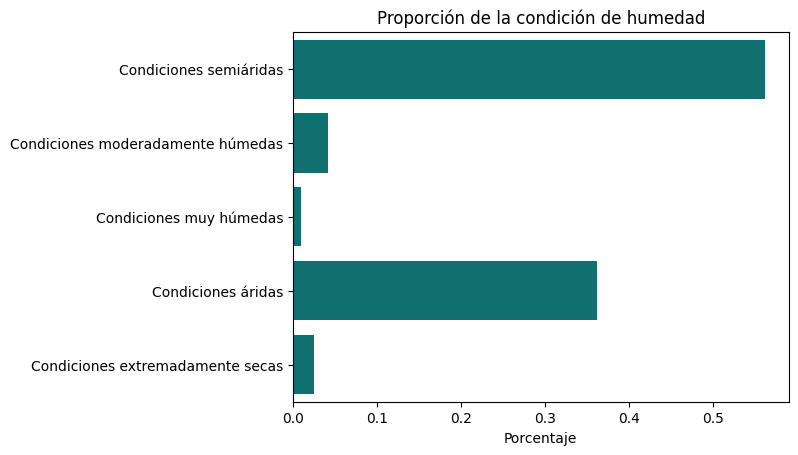

In [78]:
sns.barplot(
    y = "condicion_humedad",
    x = "proportion",
    color = "teal",
    data = datos_humedad 
    )
plt.title(
    "Proporción de la condición de humedad"
)

plt.xlabel("Porcentaje")
plt.ylabel("");